# Saudi Aviation Flight Analysis
This project analyzes flight activity at Riyadh airport to explore patterns in flight volume, airline activity, terminal usage, and flight activity across different times and days. The original dataset contains 153,308 flight records from March to October 2025.

### Load the Dataset

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_parquet("flights_RUH.parquet")

## Data Exploration

I started by exploring the dataset to understand its size, structure, data types, missing values, and main categories.

In [5]:
df.head()

,flight_number,aircraft.model,aircraft.reg,aircraft.modeS,airline.name,airline.iata,airline.icao,status,flight_type,codeshareStatus,...,origin_airport_icao,origin_airport_iata,movement.terminal,movement.quality,destination_airport_icao,destination_airport_iata,destination_airport_name,movement.airport.timeZone,movement.scheduledTime.utc,movement.scheduledTime.local
0,PF 769,Airbus A320,NaN,NaN,Air Sial,PF,NaN,Unknown,departure,Unknown,...,OERK,RUH,2,[Basic],OPIS,ISB,Islamabad,Asia/Karachi,2025-03-14 21:01Z,2025-03-15 00:01+03:00
1,XY 333,Airbus A320 NEO,HZ-NS35,710DB9,flynas,XY,KNE,Unknown,departure,IsOperator,...,OERK,RUH,1,[Basic],VILK,LKO,Lucknow,Asia/Kolkata,2025-03-14 21:05Z,2025-03-15 00:05+03:00
2,QP 568,Boeing 737,NaN,NaN,Starlight Airline,QP,SLT,Unknown,departure,Unknown,...,OERK,RUH,3,[Basic],VABB,BOM,Mumbai,Asia/Kolkata,2025-03-14 21:05Z,2025-03-15 00:05+03:00
3,F3 161,Airbus A320,NaN,NaN,flyadeal,F3,FAD,Unknown,departure,Unknown,...,OERK,RUH,5,[Basic],OEJN,JED,Jeddah,Asia/Riyadh,2025-03-14 21:10Z,2025-03-15 00:10+03:00
4,KL 423,Airbus A330-300,NaN,NaN,KLM,KL,KLM,Unknown,departure,Unknown,...,OERK,RUH,1,[Basic],OEDF,DMM,Ad Dammam,Asia/Riyadh,2025-03-14 21:15Z,2025-03-15 00:15+03:00


In [6]:
df.shape

(153308, 23)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 153308 entries, 0 to 153307
Data columns (total 23 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   flight_number                 153308 non-null  str   
 1   aircraft.model                153122 non-null  str   
 2   aircraft.reg                  36234 non-null   str   
 3   aircraft.modeS                45331 non-null   str   
 4   airline.name                  153308 non-null  str   
 5   airline.iata                  153294 non-null  str   
 6   airline.icao                  152745 non-null  str   
 7   status                        153308 non-null  str   
 8   flight_type                   153308 non-null  str   
 9   codeshareStatus               153308 non-null  str   
 10  isCargo                       153308 non-null  bool  
 11  callSign                      45137 non-null   str   
 12  origin_airport_name           153308 non-null  str   
 13  origin_air

In [8]:
df.describe()

,flight_number,aircraft.model,aircraft.reg,aircraft.modeS,airline.name,airline.iata,airline.icao,status,flight_type,codeshareStatus,...,origin_airport_icao,origin_airport_iata,movement.terminal,movement.quality,destination_airport_icao,destination_airport_iata,destination_airport_name,movement.airport.timeZone,movement.scheduledTime.utc,movement.scheduledTime.local
count,153308,153122,36234,45331,153308,153294,152745,153308,153308,153308,...,153308,153308,152458,153308,149202,149202,153308,149202,153308,153308
unique,1369,48,1431,1612,68,62,63,5,2,2,...,1,1,5,1,120,120,128,48,54364,54364
top,LH 622,Airbus A320,HZ-NS34,717CEA,Saudi Arabian,SV,SVA,Unknown,departure,Unknown,...,OERK,RUH,5,[Basic],OEJN,JED,Jeddah,Asia/Riyadh,2025-09-04 13:00Z,2025-09-04 16:00+03:00
freq,403,59394,391,390,60886,60886,60886,128618,78252,104554,...,153308,153308,80729,153308,27444,27444,27938,79413,16,16


In [32]:
df.isnull().sum()

flight_number                        0
aircraft.model                     186
aircraft.reg                    117074
aircraft.modeS                  107977
airline.name                         0
airline.iata                        14
airline.icao                       563
status                               0
flight_type                          0
codeshareStatus                      0
isCargo                              0
callSign                        108171
origin_airport_name                  0
origin_airport_icao                  0
origin_airport_iata                  0
movement.terminal                  850
movement.quality                     0
destination_airport_icao          4106
destination_airport_iata          4106
destination_airport_name             0
movement.airport.timeZone         4106
movement.scheduledTime.utc           0
movement.scheduledTime.local         0
dtype: int64

In [33]:
df.dtypes

flight_number                      str
aircraft.model                     str
aircraft.reg                       str
aircraft.modeS                     str
airline.name                       str
airline.iata                       str
airline.icao                       str
status                             str
flight_type                        str
codeshareStatus                    str
isCargo                           bool
callSign                           str
origin_airport_name                str
origin_airport_icao                str
origin_airport_iata                str
movement.terminal                  str
movement.quality                object
destination_airport_icao           str
destination_airport_iata           str
destination_airport_name           str
movement.airport.timeZone          str
movement.scheduledTime.utc         str
movement.scheduledTime.local       str
dtype: object

### Top Airlines

I checked which airlines had the highest number of flights in the dataset.

In [34]:
df.groupby("airline.name")["flight_number"].count().sort_values(ascending=False).head(10)

airline.name
Saudi Arabian    60886
flynas           33935
flyadeal         24835
Gulf Air          2198
flydubai          2059
EgyptAir          1878
Qatar             1803
Etihad            1539
Emirates          1365
Turkish           1260
Name: flight_number, dtype: int64

### Terminal Activity

I checked the number of flights handled by each terminal.

In [35]:
df.groupby("movement.terminal")["flight_number"].count().sort_values(ascending=False).head(10)

movement.terminal
5    80729
1    23420
3    22415
4    21892
2     4002
Name: flight_number, dtype: int64

### Flight Status

I checked the distribution of flight statuses in the dataset.

In [36]:
df["status"].value_counts()

status
Unknown              128618
Expected              13059
Departed              11520
Canceled                 78
CanceledUncertain        33
Name: count, dtype: int64

## Data Cleaning

After exploring the data, I created a copy of the original dataset and cleaned the columns needed for the analysis.

In [37]:
clean_df=df.copy()

In [38]:
clean_df.head()

,flight_number,aircraft.model,aircraft.reg,aircraft.modeS,airline.name,airline.iata,airline.icao,status,flight_type,codeshareStatus,...,origin_airport_icao,origin_airport_iata,movement.terminal,movement.quality,destination_airport_icao,destination_airport_iata,destination_airport_name,movement.airport.timeZone,movement.scheduledTime.utc,movement.scheduledTime.local
0,PF 769,Airbus A320,NaN,NaN,Air Sial,PF,NaN,Unknown,departure,Unknown,...,OERK,RUH,2,[Basic],OPIS,ISB,Islamabad,Asia/Karachi,2025-03-14 21:01Z,2025-03-15 00:01+03:00
1,XY 333,Airbus A320 NEO,HZ-NS35,710DB9,flynas,XY,KNE,Unknown,departure,IsOperator,...,OERK,RUH,1,[Basic],VILK,LKO,Lucknow,Asia/Kolkata,2025-03-14 21:05Z,2025-03-15 00:05+03:00
2,QP 568,Boeing 737,NaN,NaN,Starlight Airline,QP,SLT,Unknown,departure,Unknown,...,OERK,RUH,3,[Basic],VABB,BOM,Mumbai,Asia/Kolkata,2025-03-14 21:05Z,2025-03-15 00:05+03:00
3,F3 161,Airbus A320,NaN,NaN,flyadeal,F3,FAD,Unknown,departure,Unknown,...,OERK,RUH,5,[Basic],OEJN,JED,Jeddah,Asia/Riyadh,2025-03-14 21:10Z,2025-03-15 00:10+03:00
4,KL 423,Airbus A330-300,NaN,NaN,KLM,KL,KLM,Unknown,departure,Unknown,...,OERK,RUH,1,[Basic],OEDF,DMM,Ad Dammam,Asia/Riyadh,2025-03-14 21:15Z,2025-03-15 00:15+03:00


### Missing Values

I checked the percentage of missing values in each column. `aircraft.reg`, `callSign`, and `aircraft.modeS` had more than 70% missing values and were not needed for the main analysis, so I removed them.

The remaining missing values were kept because the flight records were still useful for other parts of the analysis.

In [39]:
missing_percentage = (clean_df.isnull().sum() / len(clean_df)) * 100
missing_percentage.sort_values(ascending=False)

aircraft.reg                    76.365226
callSign                        70.557962
aircraft.modeS                  70.431419
destination_airport_iata         2.678269
destination_airport_icao         2.678269
movement.airport.timeZone        2.678269
movement.terminal                0.554439
airline.icao                     0.367235
aircraft.model                   0.121324
airline.iata                     0.009132
flight_number                    0.000000
airline.name                     0.000000
status                           0.000000
codeshareStatus                  0.000000
flight_type                      0.000000
origin_airport_iata              0.000000
origin_airport_icao              0.000000
origin_airport_name              0.000000
isCargo                          0.000000
movement.quality                 0.000000
destination_airport_name         0.000000
movement.scheduledTime.utc       0.000000
movement.scheduledTime.local     0.000000
dtype: float64

In [40]:
clean_df = clean_df.drop(columns=["aircraft.reg","callSign","aircraft.modeS"])

In [41]:
clean_df.isnull().sum()

flight_number                      0
aircraft.model                   186
airline.name                       0
airline.iata                      14
airline.icao                     563
status                             0
flight_type                        0
codeshareStatus                    0
isCargo                            0
origin_airport_name                0
origin_airport_icao                0
origin_airport_iata                0
movement.terminal                850
movement.quality                   0
destination_airport_icao        4106
destination_airport_iata        4106
destination_airport_name           0
movement.airport.timeZone       4106
movement.scheduledTime.utc         0
movement.scheduledTime.local       0
dtype: int64

### Cleaning Movement Quality

The `movement.quality` values were stored as lists, so I extracted the value from each list to make the column easier to work with.

In [42]:
clean_df["movement.quality"] = clean_df["movement.quality"].str[0]

### Duplicate Rows

I found 279 duplicate rows and removed them while keeping one copy of each record.

In [43]:
clean_df = clean_df.drop_duplicates()

In [44]:
clean_df.duplicated().sum()

np.int64(0)

### Standardizing Airline Names

I checked the airline names and found that some airlines appeared under different names, so I standardized them to avoid counting the same airline separately.

In [45]:
clean_df["airline.name"].unique()

<ArrowStringArray>
[              'Air Sial',                 'flynas',      'Starlight Airline',
               'flyadeal',                    'KLM',          'Saudi Arabian',
         'China Southern',                 'IndiGo',                'British',
          'China Eastern',              'Lufthansa',               'flydubai',
                'Turkish',              'Air Cairo',                'Pegasus',
                    'ITA',              'Ethiopian',               'Emirates',
               'EgyptAir',               'Oman Air',         'Etihad Airways',
                   'AJet',                  'Qatar',               'Nile Air',
              'Air India',       'Biman Bangladesh',               'Gulf Air',
 'Pakistan International',             'Air Arabia',                 'Etihad',
                 'Kuwait',            'Middle East',                  'Nesma',
             'Serene Air',       'Air Arabia Egypt',                'Jazeera',
             'Philippine',       

In [46]:
clean_df["airline.name"] = clean_df["airline.name"].replace({"Qatar": "Qatar Airways","Etihad": "Etihad Airways"})

In [47]:
any(clean_df["airline.name"].isin(["Qatar", "Etihad"]))

False

### Converting Data Types

I converted the terminal column to numeric format and the scheduled time columns to datetime format to prepare them for analysis.

In [62]:
clean_df["movement.terminal"] = pd.to_numeric(clean_df["movement.terminal"], errors="coerce").astype("Int64")

In [63]:
clean_df["movement.scheduledTime.utc"]=pd.to_datetime( clean_df["movement.scheduledTime.utc"],errors="coerce" )

In [64]:
clean_df["movement.scheduledTime.local"]=pd.to_datetime( clean_df["movement.scheduledTime.local"],errors="coerce" )

In [65]:
clean_df.dtypes

flight_number                                         str
aircraft.model                                        str
airline.name                                          str
airline.iata                                          str
airline.icao                                          str
status                                                str
flight_type                                           str
codeshareStatus                                       str
isCargo                                              bool
origin_airport_name                                   str
origin_airport_icao                                   str
origin_airport_iata                                   str
movement.terminal                                   Int64
movement.quality                                   object
destination_airport_icao                              str
destination_airport_iata                              str
destination_airport_name                              str
movement.airpo

## Feature Engineering

I created new time-based columns from the local scheduled time to make it easier to analyze flight activity by date, month, day, hour, and time period.

In [66]:
clean_df["date"] = clean_df["movement.scheduledTime.local"].dt.date

In [67]:
clean_df["month"] = clean_df["movement.scheduledTime.local"].dt.month

In [68]:
clean_df["month_name"] = clean_df["movement.scheduledTime.local"].dt.month_name()

In [69]:
clean_df["day_of_week"] = clean_df["movement.scheduledTime.local"].dt.day_name()

In [70]:
clean_df["hour"] = clean_df["movement.scheduledTime.local"].dt.hour

In [71]:
def get_time_period(hour):
    if 0 <= hour < 6:
        return "Night"
    elif 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 18:
        return "Afternoon"
    else:
        return "Evening"

clean_df["time_period"] = clean_df["hour"].apply(get_time_period)

In [72]:
clean_df["day_type"] = "Weekday"

In [73]:
clean_df.loc[clean_df["day_of_week"].isin(["Friday", "Saturday"]), "day_type"] = "Weekend"

In [74]:
clean_df.loc[:, ["date", "month", "month_name", "day_of_week", "hour", "time_period", "day_type"]].head(10)

,date,month,month_name,day_of_week,hour,time_period,day_type
0,2025-03-15,3,March,Saturday,0,Night,Weekend
1,2025-03-15,3,March,Saturday,0,Night,Weekend
2,2025-03-15,3,March,Saturday,0,Night,Weekend
3,2025-03-15,3,March,Saturday,0,Night,Weekend
4,2025-03-15,3,March,Saturday,0,Night,Weekend
5,2025-03-15,3,March,Saturday,0,Night,Weekend
6,2025-03-15,3,March,Saturday,0,Night,Weekend
7,2025-03-15,3,March,Saturday,0,Night,Weekend
8,2025-03-15,3,March,Saturday,0,Night,Weekend
9,2025-03-15,3,March,Saturday,0,Night,Weekend


## Exploratory Data Analysis

I analyzed flight activity across different dates, days, hours, airlines, and terminals to understand the main patterns in the dataset.

### Flight Activity Over Time

In [75]:
flight_activity=clean_df["date"].value_counts().sort_index()

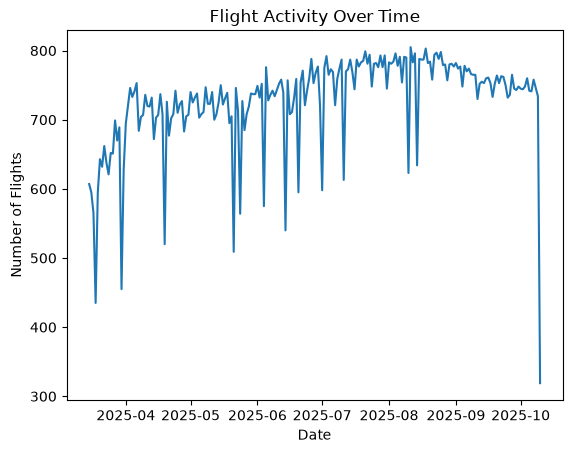

In [76]:
flight_activity.plot(kind="line")
plt.title("Flight Activity Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Flights")
plt.show()

**Observation:** Flight activity generally increases from March and reaches its highest levels around July and August, followed by a slight decrease. The large drop at the end of the chart is because the dataset only includes data until October 10.

### Flight Activity by Day of Week

In [77]:
days_in_order=["Sunday","Monday","Tuesday","Wednesday","Thursday","Friday","Saturday"]

In [78]:
day_of_week_activity=clean_df["day_of_week"].value_counts().reindex(days_in_order)

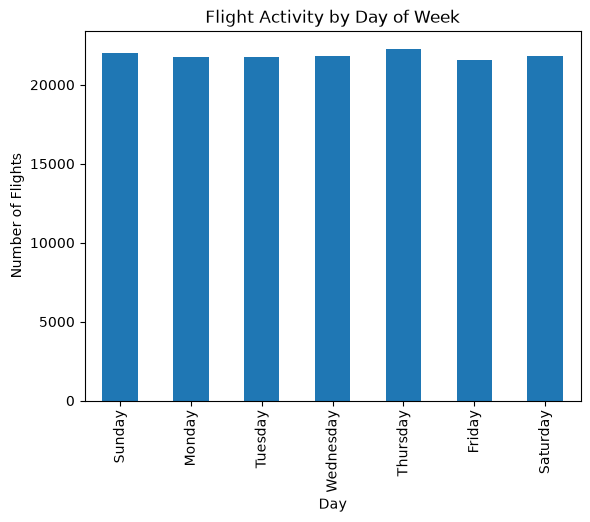

In [79]:
day_of_week_activity.plot(kind="bar")
plt.title("Flight Activity by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Flights")
plt.show()

**Observation:** Thursday has the highest flight activity, followed closely by Sunday. Overall, the number of flights is quite similar across the days of the week.

### Flight Activity by Month

In [80]:
months_in_order=["March", "April","May", "June", "July", "August","September", "October"]

In [81]:
flight_activity_by_month= clean_df["month_name"].value_counts().reindex(months_in_order)

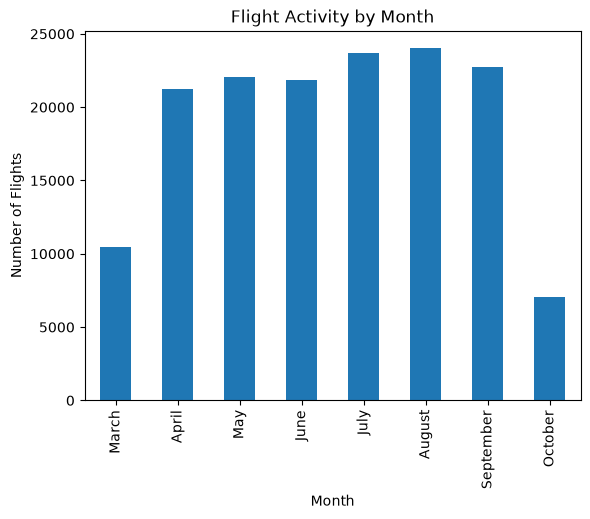

In [82]:
flight_activity_by_month.plot(kind="bar")
plt.title("Flight Activity by Month")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.show()

**Observation:** July and August have the highest number of flights. March and October have lower numbers, but both months are not complete in the dataset.

### Flight Activity by Hour

In [83]:
flight_activity_by_hour=clean_df["hour"].value_counts().sort_index()

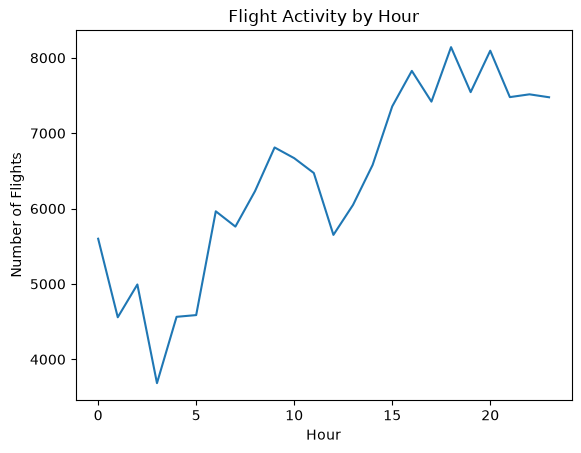

In [84]:
flight_activity_by_hour.plot(kind="line")
plt.title("Flight Activity by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Flights")
plt.show()

**Observation:** Flight activity is lower during the early morning hours, around 3–4 AM, and then starts increasing again. The highest flight activity is around 6–8 PM.

### Flight Activity by Time Period

In [85]:
time_in_order= ["Night", "Morning", "Afternoon", "Evening"]

In [86]:
flight_activity_by_time=clean_df["time_period"].value_counts().reindex(time_in_order)

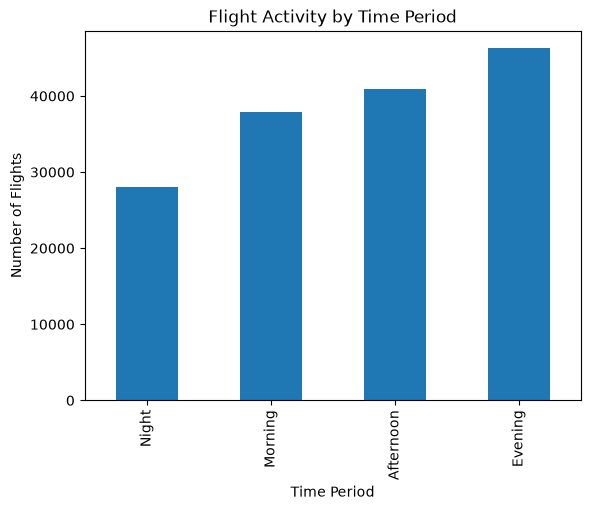

In [87]:
flight_activity_by_time.plot(kind="bar")
plt.title("Flight Activity by Time Period")
plt.xlabel("Time Period")
plt.ylabel("Number of Flights")
plt.show()

**Observation:** Evening has the highest flight activity, while Night has the lowest.

### Average Daily Flights: Weekday vs Weekend

In [88]:
daily_flights =(clean_df.groupby(["day_type", "date"])["flight_number"].count())

In [89]:
avg_daily_flights =daily_flights.groupby(level="day_type").mean()

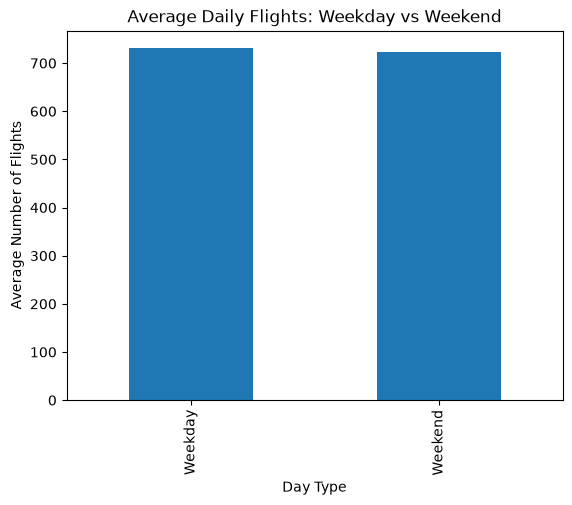

In [90]:
avg_daily_flights.plot(kind="bar")
plt.title("Average Daily Flights: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Number of Flights")
plt.show()

**Observation:** The average number of flights per day is almost the same on weekdays and weekends, with weekdays being slightly higher.

### Top 10 Airlines by Flight Volume

In [91]:
top_flight_volume=clean_df["airline.name"].value_counts().head(10)

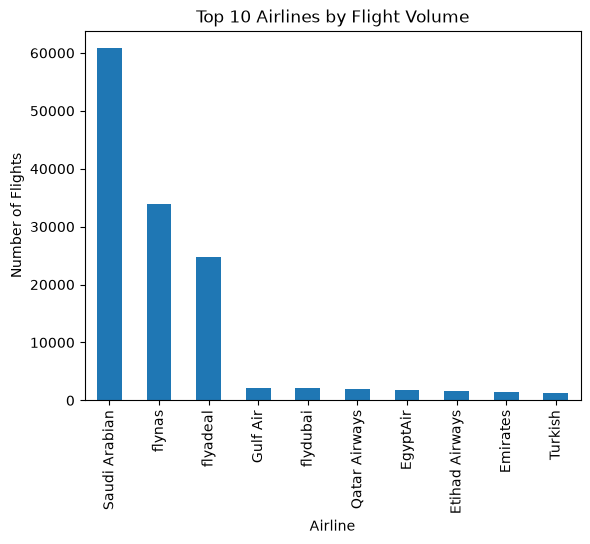

In [92]:
top_flight_volume.plot(kind="bar")
plt.title("Top 10 Airlines by Flight Volume")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")
plt.show()

**Observation:** Saudi Arabian Airlines has the highest flight volume by a large difference compared with the other airlines in the top 10.

### Flight Activity by Terminal

In [93]:
terminal_volume=clean_df["movement.terminal"].value_counts().sort_index()

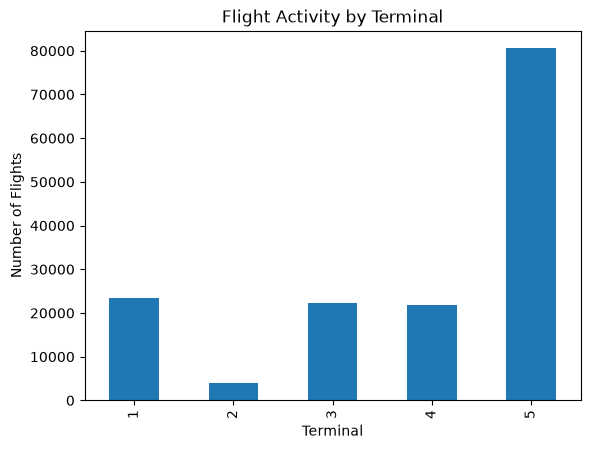

In [94]:
terminal_volume.plot(kind="bar")
plt.title("Flight Activity by Terminal")
plt.xlabel("Terminal")
plt.ylabel("Number of Flights")
plt.show()

**Observation:** Terminal 5 handles the highest flight volume by a large difference, while Terminal 2 has the lowest flight activity.

## Key Findings

- Flight activity generally increases from March and reaches its highest levels around July and August.
- Flight activity is highest during the evening, especially around 6–8 PM, while early morning hours have lower activity.
- Flight activity is fairly similar across the days of the week, with Thursday having the highest number of flights.
- The average number of flights per day is almost the same on weekdays and weekends.
- Saudi Arabian Airlines has the highest flight volume by a large difference compared with the other airlines in the top 10.
- Terminal 5 handles the highest flight volume, while Terminal 2 has the lowest.

## Export Cleaned Data

The final cleaned dataset was exported for use in Power BI.

In [73]:
clean_df.to_csv("saudi_aviation_clean.csv", index=False)